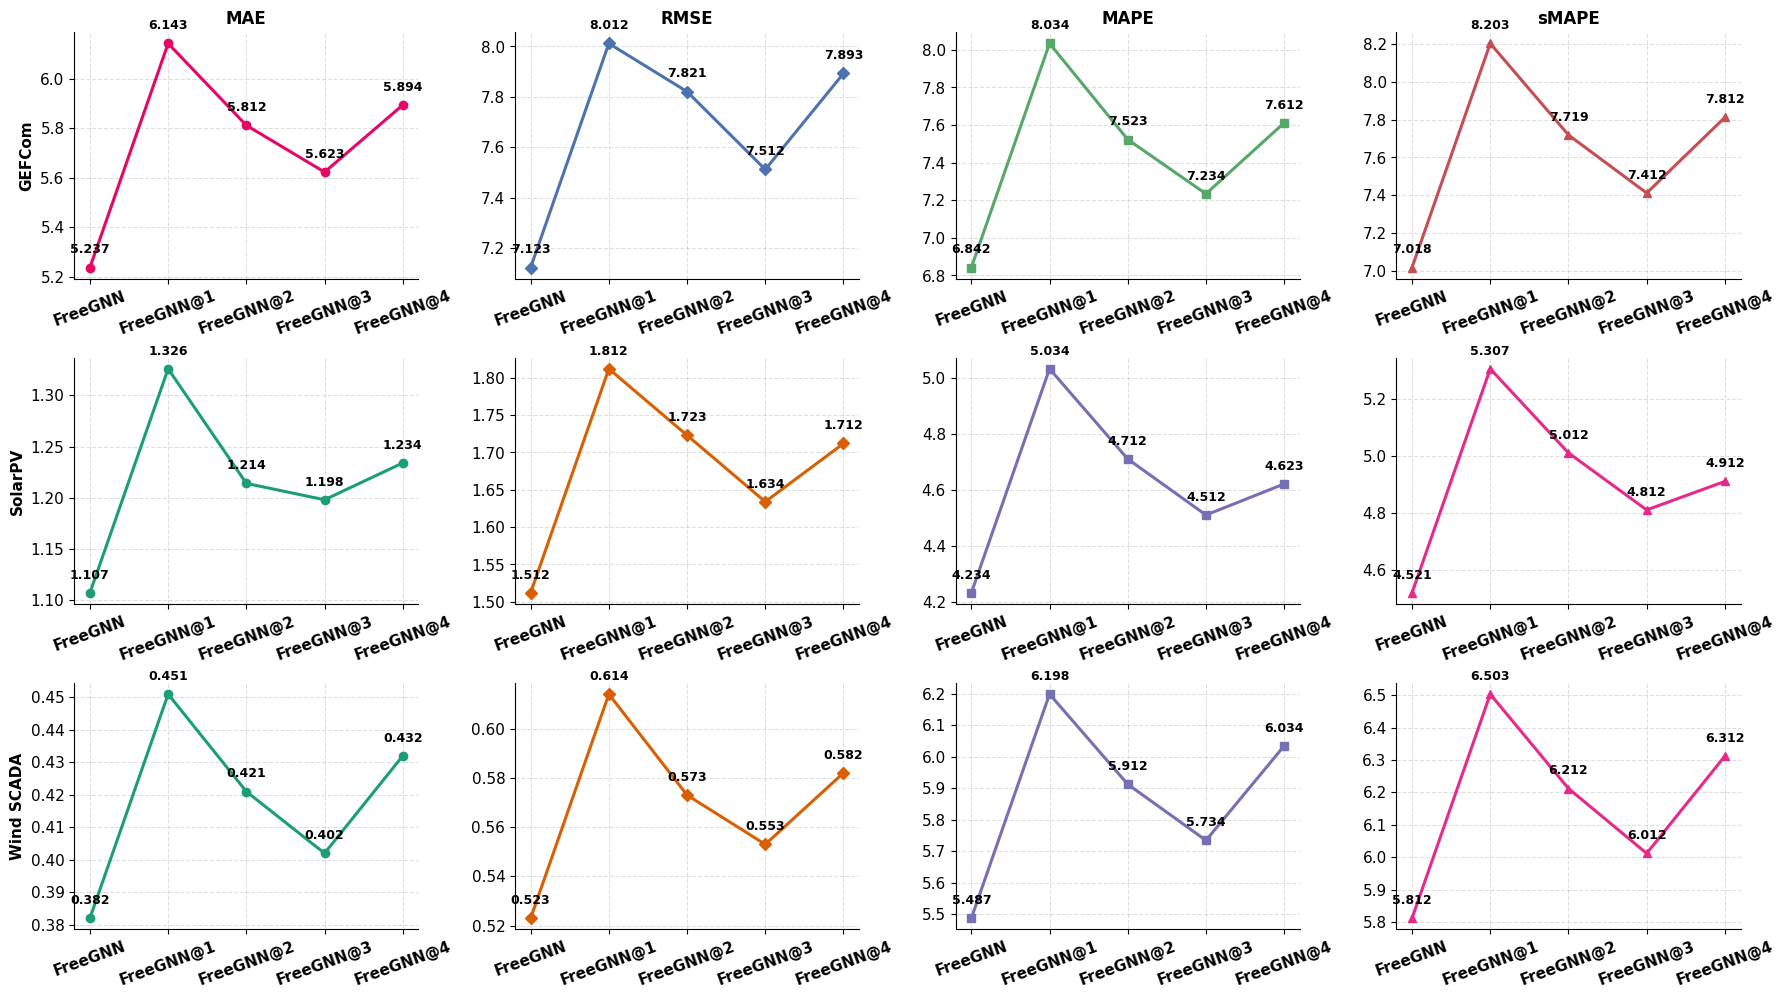

In [1]:
import matplotlib.pyplot as plt
import os

models = ["FreeGNN", "FreeGNN@1", "FreeGNN@2", "FreeGNN@3", "FreeGNN@4"]
x = range(len(models))

all_data = {
    "GEFCom": {
        "MAE": [5.237, 6.143, 5.812, 5.623, 5.894],
        "RMSE": [7.123, 8.012, 7.821, 7.512, 7.893],
        "MAPE": [6.842, 8.034, 7.523, 7.234, 7.612],
        "sMAPE": [7.018, 8.203, 7.719, 7.412, 7.812],
        "colors": ["#e80564", "#4c72b0", "#55a868", "#c44e52"]
    },
    "SolarPV": {
        "MAE": [1.107, 1.326, 1.214, 1.198, 1.234],
        "RMSE": [1.512, 1.812, 1.723, 1.634, 1.712],
        "MAPE": [4.234, 5.034, 4.712, 4.512, 4.623],
        "sMAPE": [4.521, 5.307, 5.012, 4.812, 4.912],
        "colors": ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
    },
    "Wind SCADA": {
        "MAE": [0.382, 0.451, 0.421, 0.402, 0.432],
        "RMSE": [0.523, 0.614, 0.573, 0.553, 0.582],
        "MAPE": [5.487, 6.198, 5.912, 5.734, 6.034],
        "sMAPE": [5.812, 6.503, 6.212, 6.012, 6.312],
        "colors": ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
    }
}

metrics = ["MAE", "RMSE", "MAPE", "sMAPE"]
markers = ["o", "D", "s", "^"]

plt.rcParams.update({
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})


fig, axes = plt.subplots(3, 4, figsize=(18, 12))


for row_idx, (dataset_name, dataset) in enumerate(all_data.items()):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        values = dataset[metric]
        color = dataset["colors"][col_idx]
        marker = markers[col_idx]

        ax.plot(x, values, marker=marker, linewidth=2.2, color=color)
        ax.grid(True, linestyle="--", alpha=0.4)

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(dataset_name, fontsize=11, fontweight="bold")
        else:
            ax.set_ylabel("")

        y_range = max(values) - min(values)
        offset = y_range * 0.05 if y_range != 0 else 0.02

        for i, v in enumerate(values):
            ax.text(i, v + offset,
                    f"{v:.3f}",
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight="bold")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row_idx == 0:
            ax.set_title(metric, fontsize=12, fontweight="bold")
            
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.subplots_adjust(bottom=0.15)  

plt.savefig("/kaggle/working/AllDatasets_Ablation_Clean.pdf",
            format="pdf",
            bbox_inches="tight",
            dpi=600)
plt.show()